In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureEMOVO.csv')

In [ ]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,labels,speaker
0,-370.303223,58.331867,-7.632109,15.654898,3.273010,0.692397,-8.063744,5.894156,-5.199350,12.546567,...,34.036367,-0.028319,0.053574,-0.043633,-0.009186,0.019449,-0.007346,1,1,1
1,-374.553833,47.796314,1.653561,20.256063,-6.800525,0.783256,-4.250007,7.473405,-15.591282,14.261038,...,34.229551,0.023288,0.050375,-0.021473,0.040849,0.002533,0.025532,1,1,1
2,-386.473145,75.599594,-15.072874,6.823948,-1.835993,-4.165404,-10.107768,7.045069,-17.148949,11.959360,...,34.157690,0.013844,0.000709,-0.032024,-0.007825,0.018322,0.016368,1,1,1
3,-362.502167,89.977379,-15.514508,5.774208,4.361949,12.591103,-0.374380,-0.392911,-4.743288,15.702434,...,32.441757,0.002924,0.020344,-0.057423,0.041032,-0.014291,-0.002126,1,1,1
4,-412.010406,83.760246,-2.188665,18.547068,0.581788,10.956905,3.381726,3.320800,-9.278383,11.129302,...,33.286765,0.001819,0.007893,-0.003650,0.014794,0.000603,0.001663,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686,2,7,6
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550,2,7,6
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411,2,7,6
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469,2,7,6


In [4]:
import joblib

# Load the saved scaler
scaler = joblib.load("../scaler.pkl")

# Load the saved model
gender_model = tf.keras.models.load_model("../gender_classification_model.h5")

W0000 00:00:1761899871.337009 2624229 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
X_gender = data.iloc[:, :193].values
X_scaled = scaler.transform(X_gender)
gender_predictions = gender_model.predict(X_scaled)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [6]:
print(gender_predictions)

[[9.9828970e-01]
 [9.9834955e-01]
 [9.9788028e-01]
 [9.9732769e-01]
 [9.9635899e-01]
 [9.9681473e-01]
 [9.9819213e-01]
 [9.9821997e-01]
 [9.9777019e-01]
 [9.9752653e-01]
 [9.9899632e-01]
 [9.9829251e-01]
 [9.9259490e-01]
 [9.9883544e-01]
 [9.9857998e-01]
 [9.9836719e-01]
 [9.9859685e-01]
 [9.9865657e-01]
 [9.9904752e-01]
 [9.9894178e-01]
 [9.9887395e-01]
 [9.9902785e-01]
 [9.9886918e-01]
 [9.9660271e-01]
 [9.9910802e-01]
 [9.9861097e-01]
 [9.9921095e-01]
 [9.9864632e-01]
 [9.9833751e-01]
 [9.9734801e-01]
 [9.9912602e-01]
 [9.9823749e-01]
 [9.9529636e-01]
 [9.9960870e-01]
 [9.9931926e-01]
 [9.9927300e-01]
 [9.9961668e-01]
 [9.9883544e-01]
 [9.9958110e-01]
 [9.9931502e-01]
 [9.9954695e-01]
 [9.9962139e-01]
 [9.9546325e-01]
 [9.9178624e-01]
 [9.9855840e-01]
 [9.9614286e-01]
 [9.9655396e-01]
 [9.9774104e-01]
 [9.9800879e-01]
 [9.9872130e-01]
 [9.9872756e-01]
 [9.9804991e-01]
 [9.9869490e-01]
 [9.9843967e-01]
 [9.9707711e-01]
 [9.9824804e-01]
 [9.9754053e-01]
 [9.9541563e-01]
 [9.9929971e-0

In [7]:
male_rows = gender_predictions.flatten() < 0.5  # 0 for Male, 1 for Female

df = data[male_rows]

print(f"Filtered dataset contains {df.shape[0]} male samples.")

Filtered dataset contains 294 male samples.


In [8]:
df.shape

(294, 196)

In [9]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,labels,speaker
294,-225.834305,83.962433,-5.286817,35.728619,-13.078013,17.963274,-14.742523,4.787130,-3.795607,9.062120,...,33.802033,0.018696,-0.009439,-0.011013,-0.002207,0.014388,0.001134,2,1,4
295,-248.242477,88.256699,2.077917,48.205994,-14.475659,10.191969,-9.108829,11.997128,-4.937069,9.115414,...,36.425106,-0.046464,-0.000673,-0.018350,0.024076,-0.030521,-0.010057,2,1,4
296,-288.580505,113.707069,-4.207919,36.642605,-7.948632,9.709131,-5.470535,5.543427,-0.030859,12.137795,...,34.574195,0.012381,-0.029587,-0.049667,-0.048555,-0.004218,0.019347,2,1,4
297,-264.005371,79.057182,-11.777345,39.176647,-14.728073,30.268671,-1.693096,4.519373,-3.846275,14.705531,...,34.959960,0.004540,0.010262,-0.001896,0.026106,-0.010619,0.014993,2,1,4
298,-319.776733,82.874512,-2.986594,41.945034,-8.119583,26.139738,0.383493,3.180753,-3.732891,11.955462,...,34.708427,-0.009257,-0.019991,0.067884,-0.045997,0.002260,0.011251,2,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686,2,7,6
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550,2,7,6
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411,2,7,6
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469,2,7,6


In [10]:
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [11]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
294,-225.834305,83.962433,-5.286817,35.728619,-13.078013,17.963274,-14.742523,4.787130,-3.795607,9.062120,...,13.788023,16.202099,16.689351,33.802033,0.018696,-0.009439,-0.011013,-0.002207,0.014388,0.001134
295,-248.242477,88.256699,2.077917,48.205994,-14.475659,10.191969,-9.108829,11.997128,-4.937069,9.115414,...,14.467161,15.449994,17.459077,36.425106,-0.046464,-0.000673,-0.018350,0.024076,-0.030521,-0.010057
296,-288.580505,113.707069,-4.207919,36.642605,-7.948632,9.709131,-5.470535,5.543427,-0.030859,12.137795,...,14.419935,16.330941,18.172192,34.574195,0.012381,-0.029587,-0.049667,-0.048555,-0.004218,0.019347
297,-264.005371,79.057182,-11.777345,39.176647,-14.728073,30.268671,-1.693096,4.519373,-3.846275,14.705531,...,13.489356,16.934286,15.906022,34.959960,0.004540,0.010262,-0.001896,0.026106,-0.010619,0.014993
298,-319.776733,82.874512,-2.986594,41.945034,-8.119583,26.139738,0.383493,3.180753,-3.732891,11.955462,...,13.730269,16.036330,17.712544,34.708427,-0.009257,-0.019991,0.067884,-0.045997,0.002260,0.011251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,16.535757,15.881800,18.443654,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,16.113687,16.514813,18.799787,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,14.285399,16.010688,18.472471,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,14.503504,15.854289,17.343597,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469


In [12]:
y

294    1
295    1
296    1
297    1
298    1
      ..
583    7
584    7
585    7
586    7
587    7
Name: labels, Length: 294, dtype: int64

In [13]:
X.shape, y.shape

((294, 193), (294,))

In [14]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [15]:
y1

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(294, 7))

In [16]:
X.shape, y1.shape

((294, 193), (294, 7))

In [17]:
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [18]:
X2.shape, y2.shape

((294, 193), (294,))

In [19]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(7))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    return model

In [20]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [21]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-225.834305,83.962433,-5.286817,35.728619,-13.078013,17.963274,-14.742523,4.787130,-3.795607,9.062120,...,13.788023,16.202099,16.689351,33.802033,0.018696,-0.009439,-0.011013,-0.002207,0.014388,0.001134
1,-248.242477,88.256699,2.077917,48.205994,-14.475659,10.191969,-9.108829,11.997128,-4.937069,9.115414,...,14.467161,15.449994,17.459077,36.425106,-0.046464,-0.000673,-0.018350,0.024076,-0.030521,-0.010057
2,-288.580505,113.707069,-4.207919,36.642605,-7.948632,9.709131,-5.470535,5.543427,-0.030859,12.137795,...,14.419935,16.330941,18.172192,34.574195,0.012381,-0.029587,-0.049667,-0.048555,-0.004218,0.019347
3,-264.005371,79.057182,-11.777345,39.176647,-14.728073,30.268671,-1.693096,4.519373,-3.846275,14.705531,...,13.489356,16.934286,15.906022,34.959960,0.004540,0.010262,-0.001896,0.026106,-0.010619,0.014993
4,-319.776733,82.874512,-2.986594,41.945034,-8.119583,26.139738,0.383493,3.180753,-3.732891,11.955462,...,13.730269,16.036330,17.712544,34.708427,-0.009257,-0.019991,0.067884,-0.045997,0.002260,0.011251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,16.535757,15.881800,18.443654,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686
290,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,16.113687,16.514813,18.799787,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550
291,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,14.285399,16.010688,18.472471,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411
292,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,14.503504,15.854289,17.343597,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469


In [22]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=290
num_fea=125
a=create_index(kfold,totalsize)
savedir='emovo_gender_male_193'

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=kfold, shuffle=True, random_state=42)

fold = 0
for train_idx, test_idx in skf.split(X3, y2):
    print(f"\n===== Fold {fold} =====")
    print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")

    # Split data
    X_train, X_test = X3.iloc[train_idx, :], X3.iloc[test_idx, :]
    y_train, y_test = y1[train_idx, :], y1[test_idx, :]

    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_scaled, axis=2)
    x_testcnn = np.expand_dims(X_test_scaled, axis=2)

    # Build and compile model
    m1 = model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {fold} Test Accuracy: {score_eval[1]:.4f}")

    # Save test data for reproducibility
    np.save(os.path.join(savedir, f"X_test_fold{fold}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{fold}.npy"), y_test)

    # Save model
    model_name = f"Model_{fold}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{fold}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)

    fold += 1

print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")
    


===== Fold 0 =====
Train: 235 | Test: 59
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.1830 - loss: 2.0758 - val_accuracy: 0.1525 - val_loss: 1.9374
Epoch 2/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3915 - loss: 1.5789 - val_accuracy: 0.1356 - val_loss: 1.9340
Epoch 3/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4638 - loss: 1.4087 - val_accuracy: 0.1356 - val_loss: 1.9334
Epoch 4/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5489 - loss: 1.3168 - val_accuracy: 0.1356 - val_loss: 1.9364
Epoch 5/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6255 - loss: 1.1737 - val_accuracy: 0.1356 - val_loss: 1.9385
Epoch 6/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6596 - loss: 1.1414 - val_accuracy: 0.1356 - val_loss: 1.9386
Epoch 7/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7319 - loss: 1.0531 - val_accuracy: 0.1356 - val_loss: 1.9412
Epoch 8/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7745 - loss: 0.9824 - val_accuracy: 0.1356 - val_loss: 1.9431
Epo

Fold 0 Test Accuracy: 0.7797

===== Fold 1 =====
Train: 235 | Test: 59


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Epoch 1/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.2936 - loss: 1.9462 - val_accuracy: 0.2542 - val_loss: 1.9353
Epoch 2/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4894 - loss: 1.4464 - val_accuracy: 0.1864 - val_loss: 1.9427
Epoch 3/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5660 - loss: 1.3010 - val_accuracy: 0.1525 - val_loss: 1.9494
Epoch 4/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6340 - loss: 1.1875 - val_accuracy: 0.1864 - val_loss: 1.9556
Epoch 5/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6340 - loss: 1.1936 - val_accuracy: 0.1695 - val_loss: 1.9597
Epoch 6/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7106 - loss: 1.0993 - val_accuracy: 0.1864 - val_loss: 1.9665
Epoch 7/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6894 - loss: 1.0948 - val_accuracy: 0.1525 - val_loss: 1.9729
Epoch 8/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.7702 - loss: 0.9822 - val_accuracy: 0.1356 - val_loss:

Fold 3 Test Accuracy: 0.8644

===== Fold 4 =====
Train: 236 | Test: 58


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.2542 - loss: 1.9186 - val_accuracy: 0.2414 - val_loss: 1.9183
Epoch 2/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4025 - loss: 1.4935 - val_accuracy: 0.2069 - val_loss: 1.9189
Epoch 3/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5424 - loss: 1.3455 - val_accuracy: 0.1207 - val_loss: 1.9254
Epoch 4/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5847 - loss: 1.2375 - val_accuracy: 0.1552 - val_loss: 1.9283
Epoch 5/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6737 - loss: 1.1578 - val_accuracy: 0.1897 - val_loss: 1.9353
Epoch 6/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.6568 - loss: 1.1276 - val_accuracy: 0.2069 - val_loss: 1.9399
Epoch 7/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7161 - loss: 1.0784 - val_accuracy: 0.2241 - val_loss: 1.9423
Epoch 8/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7331 - loss: 0.9741 - val_accuracy: 0.2414 - val_loss:

Fold 4 Test Accuracy: 0.8276

===== Cross-validation results =====
Fold 0: Loss=0.9936, Accuracy=0.7797
Fold 1: Loss=0.9816, Accuracy=0.8644
Fold 2: Loss=0.9970, Accuracy=0.8644
Fold 3: Loss=0.9783, Accuracy=0.8644
Fold 4: Loss=1.0153, Accuracy=0.8276

Average accuracy: 0.8401


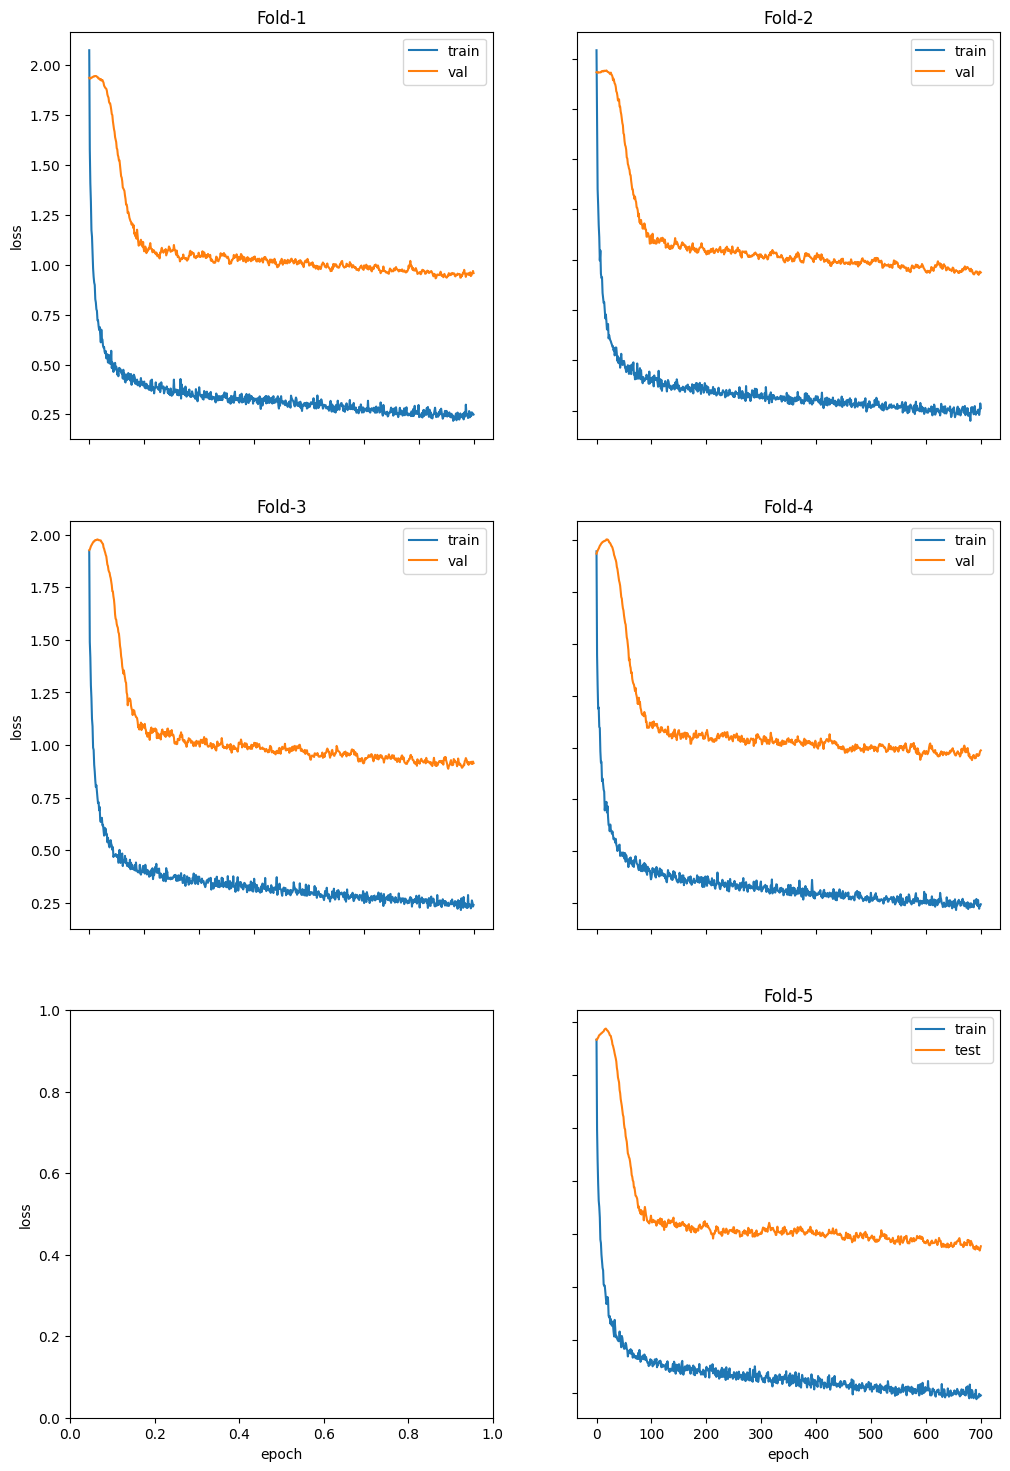

In [23]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(3, 2,figsize=(12,18))
axs[0, 0].plot(hist[0].history['loss'])
axs[0, 0].plot(hist[0].history['val_loss'])
axs[0, 0].set_title('Fold-1')
axs[0, 0].legend(['train', 'val'], loc='upper right')

axs[0, 1].plot(hist[1].history['loss'])
axs[0, 1].plot(hist[1].history['val_loss'])
axs[0, 1].set_title('Fold-2')
axs[0, 1].legend(['train', 'val'], loc='upper right')

axs[1, 0].plot(hist[2].history['loss'])
axs[1, 0].plot(hist[2].history['val_loss'])
axs[1, 0].set_title('Fold-3')
axs[1, 0].legend(['train', 'val'], loc='upper right')

axs[1, 1].plot(hist[3].history['loss'])
axs[1, 1].plot(hist[3].history['val_loss'])
axs[1, 1].set_title('Fold-4')
axs[1, 1].legend(['train', 'val'], loc='upper right')

axs[2, 1].plot(hist[4].history['loss'])
axs[2, 1].plot(hist[4].history['val_loss'])
axs[2, 1].set_title('Fold-5')
axs[2, 1].legend(['train', 'test'], loc='upper right')

for ax in axs.flat:
    ax.set(xlabel='epoch', ylabel='loss')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()
fig.savefig('emovoMale_4Folds_65.png')

In [2]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix, classification_report

savedir = 'emovo_gender_male_193'
num_folds = 5
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices_male = []

listik = ['dis', 'gio', 'neu', 'pau', 'rab', 'sor', 'tri']

fold_reports = []
fold_macro_f1 = []

for i in range(num_folds):
    model_name = f"Model_{i}"
    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")
    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices_male.append(cm)

    report_dict = classification_report(y_true_labels, y_pred_labels,
                                        target_names=listik, digits=4, output_dict=True)
    fold_reports.append(report_dict)
    fold_macro_f1.append(report_dict['macro avg']['f1-score'])

    print(f"\n{'='*60}")
    print(f"Fold {i}: Accuracy = {acc:.2f}%")
    print(f"{'='*60}")
    print(classification_report(y_true_labels, y_pred_labels,
                                target_names=listik, digits=4))

# array: (num_folds, num_classes, num_classes)
conf_matrices_male = np.array(conf_matrices_male)

mean_acc = np.mean(accuracies)
print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))
n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")


# Macro-F1 summary
macro_f1_arr = np.array(fold_macro_f1)
mean_macro_f1 = np.mean(macro_f1_arr)
std_macro_f1 = np.std(macro_f1_arr)
ci95_f1 = 1.96 * (std_macro_f1 / np.sqrt(num_folds))
print(f"\nMacro-F1: {mean_macro_f1:.4f} ± {std_macro_f1:.4f}  "
      f"\n95% CI: [{mean_macro_f1 - ci95_f1:.4f}, {mean_macro_f1 + ci95_f1:.4f}]")

# Per-class precision / recall / F1 (mean ± SD across folds)
print(f"\n{' Per-Class Metrics (mean ± SD across folds)':=^93}\n")
print(f"{'Class':<12} {'Precision':>20} {'Recall':>20} {'F1-Score':>20} {'Support':>17}")
print("-" * 93)
for cls in listik:
    p = np.array([r[cls]['precision'] for r in fold_reports])
    r = np.array([r[cls]['recall'] for r in fold_reports])
    f = np.array([r[cls]['f1-score'] for r in fold_reports])
    s = np.array([r[cls]['support'] for r in fold_reports])
    print(f"{cls:<12}        "
          f"{np.mean(p):>6.4f} ± {np.std(p):<6.4f}       "
          f"{np.mean(r):>6.4f} ± {np.std(r):<6.4f}       "
          f"{np.mean(f):>6.4f} ± {np.std(f):<6.4f}     "
          f"{np.mean(s):>8.1f}")
print("-" * 93)

2026-03-02 12:05:44.325589: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-02 12:05:44.325798: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 12:05:44.352312: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 12:05:45.103972: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or


Fold 0: Accuracy = 77.97%
              precision    recall  f1-score   support

         dis     0.7273    0.8889    0.8000         9
         gio     0.6667    0.5000    0.5714         8
         neu     1.0000    1.0000    1.0000         9
         pau     0.6667    0.5000    0.5714         8
         rab     0.6364    0.8750    0.7368         8
         sor     0.8571    0.6667    0.7500         9
         tri     0.8889    1.0000    0.9412         8

    accuracy                         0.7797        59
   macro avg     0.7776    0.7758    0.7673        59
weighted avg     0.7818    0.7797    0.7715        59


Fold 1: Accuracy = 86.44%
              precision    recall  f1-score   support

         dis     0.6364    0.7778    0.7000         9
         gio     1.0000    0.7500    0.8571         8
         neu     1.0000    1.0000    1.0000         8
         pau     0.8571    0.6667    0.7500         9
         rab     1.0000    1.0000    1.0000         8
         sor     0.8889 

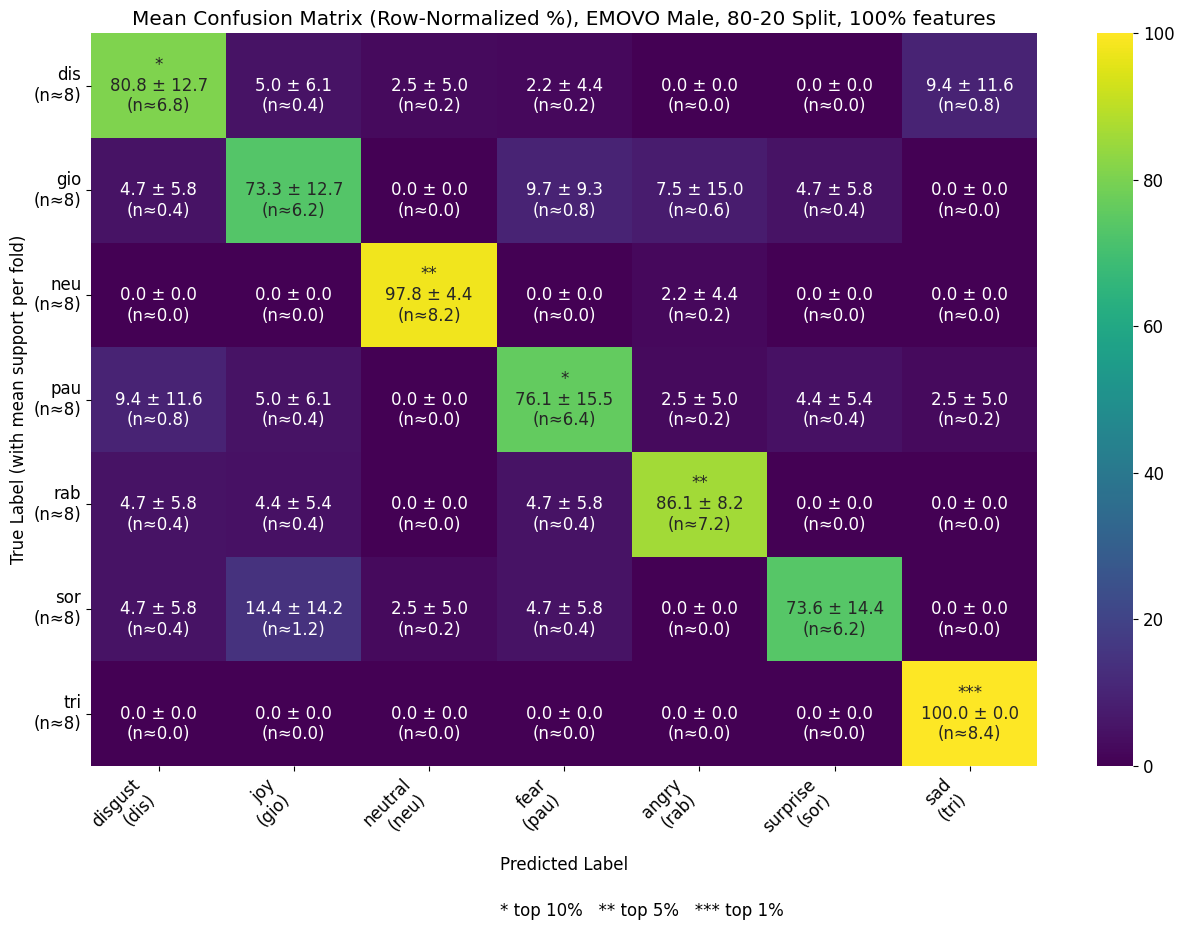

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 12})

# Row-normalized percentages
conf_matrices_percent = conf_matrices_male / conf_matrices_male.sum(axis=2, keepdims=True) * 100
np.save('cm_emovo_gender_male_193.npy', conf_matrices_percent)

mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

# Mean raw counts per fold
mean_counts = np.mean(conf_matrices_male, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols + raw counts
labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        val = mean_cm[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels[i, j] = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}\n(n≈{mean_counts[i, j]:.1f})"

y_list = ['dis', 'gio', 'neu', 'pau', 'rab', 'sor', 'tri']
x_list = ['disgust\n(dis)', 'joy\n(gio)', 'neutral\n(neu)','fear\n(pau)', 'angry\n(rab)', 'surprise\n(sor)', 'sad\n(tri)']

# Per-class support (mean samples per true class per fold)
mean_support = np.mean(conf_matrices_male.sum(axis=2), axis=0)
row_labels = [f"{name}\n(n≈{sup:.0f})" for name, sup in zip(listik, mean_support)]

# Plot
plt.figure(figsize=(13, 9))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)
ax.set_xticks(np.arange(len(x_list)) + 0.5)
ax.set_yticks(np.arange(len(y_list)) + 0.5)
ax.set_xticklabels(x_list, rotation=45, ha="right")
ax.set_yticklabels(row_labels, rotation=0)
plt.title("Mean Confusion Matrix (Row-Normalized %), EMOVO Male, 80-20 Split, 100% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label (with mean support per fold)")
plt.tight_layout()
plt.figtext(0.5, -0.05,
            "* top 10%   ** top 5%   *** top 1%\n",
            ha="center", fontsize=12)
plt.show()